In [51]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import sample_8gaussians, sample_moons, torch_wrapper

savedir = "models/2d"
os.makedirs(savedir, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
class torch_wrapper(torch.nn.Module):
    """Wraps model to torchdyn compatible format."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x, *args, **kwargs):
        return self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))


def exact_div_fn(u):
    """Accepts a function u:R^D -> R^D."""
    J = torch.func.jacrev(u)
    return lambda x, *args: torch.trace(J(x))


def div_fn_hutch_trace(u):
    def div_fn(x, eps):
        _, vjpfunc = torch.func.vjp(u, x)
        return (vjpfunc(eps)[0] * eps).sum()

    return div_fn


class cnf_wrapper(torch.nn.Module):
    """Wraps model to a torchdyn compatible CNF format.
    Appends an additional dimension representing the change in likelihood
    over time.
    """

    def __init__(self, model, likelihood_estimator="exact"):
        super().__init__()
        self.model = model
        self.div_fn, self.eps_fn = self.get_div_and_eps(likelihood_estimator)

    def get_div_and_eps(self, likelihood_estimator):
        if likelihood_estimator == "exact":
            return exact_div_fn, None
        if likelihood_estimator == "hutch_gaussian":
            return div_fn_hutch_trace, torch.randn_like
        if likelihood_estimator == "hutch_rademacher":

            def eps_fn(x):
                return torch.randint_like(x, low=0, high=2).float() * 2 - 1.0

            return div_fn_hutch_trace, eps_fn
        raise NotImplementedError(
            f"likelihood estimator {likelihood_estimator} is not implemented"
        )

    def forward(self, t, x, *args, **kwargs):
        t = t.squeeze()
        x = x[..., :-1]

        def vecfield(y):
            return self.model(torch.cat([y, t[None]]))

        if self.eps_fn is None:
            div = torch.vmap(self.div_fn(vecfield))(x)
        else:
            div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        dx = self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))
        return torch.cat([dx, div[:, None]], dim=-1)

In [152]:
import pdb

from torch.distributions import Normal, Independent

def log_prob_standard_normal(x):
    """
    x: Tensor of shape (N, D), samples for which we want log-prob under a standard normal.
    Returns: log_probs of shape (N,), where log_probs[i] = log p(x[i]) under N(0,I).
    """
    # Suppose x is D-dimensional. We create a Normal(0,1) for each dimension,
    # then make it a D-dimensional distribution with 'Independent'.
    D = x.size(-1)
    dist = Independent(Normal(loc=torch.zeros(D, device=x.device),
                              scale=torch.ones(D, device=x.device)), 
                       reinterpreted_batch_ndims=1)
    return dist.log_prob(x)

class SDEBase(nn.Module):
    def __init__(self, eps=1e-5, rescale=False):
        super().__init__()
        self.eps = eps
        self.rescale = rescale

    def drift_coef(self, x, t):
        pass
    
    def diffusion_coef(self, t):
        pass
    
    def x0_coef(self, t):
        pass
    
    def sigma_t(self, t):
        pass

    def match_dim(self, x, y):
        while len(x.shape) < len(y.shape):
            x = x.unsqueeze(-1)
        return x

    def forward(self, model, x, t):
        score = model(torch.cat([x, t[:, None]], dim=-1))
        if self.rescale:
            sigma = self.sigma_t(t)
            while len(sigma.shape) < len(x.shape):
                sigma = sigma.unsqueeze(-1)
            score = score / sigma
        
        return score
    
    def q_sample(self, x_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        s_t = self.sigma_t(t)
        x0_coef = self.x0_coef(t)
        s_t = self.match_dim(s_t, x_0)
        x0_coef = self.match_dim(x0_coef, x_0)
        
        return x0_coef * x_0 + s_t * noise
    
    def sample_time_batch(self, batch_size, device=None):
        return (self.eps - 1) * torch.rand(batch_size, device=device) + 1
    
    def score_matching_loss(self, model, x):
        time = self.sample_time_batch(x.shape[0], x.device)
        noise = torch.randn_like(x)
        x_t = self.q_sample(x, time, noise)
        score = self.forward(model, x_t, time)
        sigma = self.sigma_t(time)
        sigma = self.match_dim(sigma, x)
        loss = torch.mean(torch.sum((sigma * score + noise) ** 2, dim=(1)))

        return loss
    
    @torch.no_grad()
    def euler_maruyama_step(self, model, x, t, delta_t):
        score = self.forward(model, x, t)
        g = self.diffusion_coef(t)
        g = self.match_dim(g, x)
        
        if t[0] == self.eps:
            z = 0
        else:
            z = torch.randn_like(x)

        noise_t = np.sqrt(delta_t) * z
        drift = self.drift_coef(x, t)
        x_mean = x - (drift - (g**2) * score) * delta_t
        x_new = x_mean + g * noise_t
        dlogp = self.dlogp(score, drift, g, noise_t, x, x_new, t, delta_t)
        return x_new, dlogp
        
    def dlogp(self, score_t, drift, g, noise_t, x, x_new, t, dt):
        # pdb.set_trace()
        dlogp = 0 # (0.5*self.beta_t(t) * x.size(-1) * dt)
        dlogp = dlogp + ((-0.5*(g**2)* (torch.norm(score_t, dim=-1, keepdim=True)**2))).sum(-1) * dt + (g*(score_t * noise_t)).sum(-1)
        return dlogp

    @torch.no_grad()
    def euler_maruyama_sample(self, model, shape, device, n_steps=500):
        x_t = torch.randn(shape).to(device)
        time_steps = np.linspace(1, self.eps, n_steps)
        delta_t = time_steps[0] - time_steps[1]
        logp = log_prob_standard_normal(x_t)
        for t in tqdm(time_steps):
            time_batch = torch.ones(shape[0], device=device) * t
            x_t, dlogp = self.euler_maruyama_step(model, x_t, time_batch, delta_t)
            logp = logp + dlogp
        return x_t, logp
    
    @torch.no_grad()
    def langevin_step(self, model, x, t, snr=0.16):
        score = self.forward(model, x, t)
        noise = torch.randn_like(x)
        score_norm = torch.norm(score.reshape(score.shape[0], -1), dim=-1).mean()
        noise_norm = np.sqrt(np.prod(x.shape[1:]))
        step_size = 2 * (snr * noise_norm / score_norm)**2

        x = x + step_size * score + torch.sqrt(2 * step_size) * noise

        return x
    
    @torch.no_grad()
    def predictor_corrector_step(self, model, x, t, delta_t, n_lang_steps=1, snr=0.16):
        for i in range(n_lang_steps):
            x = self.langevin_step(model, x, t, snr)

        x = self.euler_maruyama_step(model, x, t, delta_t)
        
        return x
    
    @torch.no_grad()
    def predictor_corrector_sample(self, model, shape, device, n_steps=500, n_lang_steps=1, snr=0.16):
        x_t = torch.randn(shape).to(device)
        time_steps = np.linspace(1, self.eps, n_steps)
        delta_t = time_steps[0] - time_steps[1]
        for t in tqdm(time_steps):
            time_batch = torch.ones(shape[0], device=device) * t
            x_t = self.predictor_corrector_step(model, x_t, time_batch, delta_t, n_lang_steps, snr)

        return x_t

    
class VE_SDE(SDEBase):
    '''
    An SDE version of NCSN
    '''
    def __init__(self, sigma_min=0.01, sigma_max=1., eps=1e-5, rescale=True):
        super().__init__(eps, rescale)
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max

    def drift_coef(self, x, t):
        return torch.zeros_like(x)

    def sigma_t(self, t):
        return self.sigma_min * (self.sigma_max / self.sigma_min) ** t
    
    def diffusion_coef(self, t):
        s_t = self.sigma_t(t)
        return s_t * np.sqrt(2 * np.log(self.sigma_max / self.sigma_min))
    
    def x0_coef(self, t):
        return torch.ones_like(t)

class VP_SDE(SDEBase):
    '''
    An SDE version of DDPM.
    '''
    def __init__(self, beta_min=0.1, beta_max=20., eps=1e-5, rescale=True):
        super().__init__(eps, rescale)
        self.beta_min = beta_min
        self.beta_max = beta_max

    def beta_t(self, t):
        return self.beta_min + t * (self.beta_max - self.beta_min)

    def drift_coef(self, x, t):
        drift = self.beta_t(t)
        drift = self.match_dim(drift, x)
        drift = - drift * x / 2
        return drift
    
    def diffusion_coef(self, t):
        return torch.sqrt(self.beta_t(t))
    
    def x0_coef(self, t):
        x = - t**2 * (self.beta_max - self.beta_min) / 4
        x = x - t * self.beta_min / 2
        return torch.exp(x)
    
    def sigma_t(self, t):
        x = self.x0_coef(t)
        return torch.sqrt(1 - x**2)

In [143]:
def plot_trajectories_sb(traj, legend=True):
    n = 2000
    plt.figure(figsize=(10, 10))
    plt.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    plt.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    plt.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(5, 15):
        plt.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    plt.xticks([])
    plt.yticks([])
    plt.axis("off")

In [144]:
class EnergyModel(torch.nn.Module):
    def __init__(self, v):
        super().__init__()
        self.v = v
    def forward(self, x):
        t = x[:, -1]
        #one_over_two_sigma_t_squared = torch.clip(t / torch.clip(4 * (1 - t), min=1e-2), min=1e-2, max=1e-2)
        return ((self.v(x) - x[:, :-1]) ** 2).sum(-1)
        
class GradModel(torch.nn.Module):
    def __init__(self, action):
        super().__init__()
        self.action = action

    def forward(self, x):
        with torch.enable_grad():
            x = x.requires_grad_(True)
            grad = torch.autograd.grad(torch.sum(self.action(x)), x, create_graph=True)[0]
            return grad[:, :-1]

class MLP2(torch.nn.Module):
    def __init__(self, dim, out_dim=None, w=64, time_varying=True):
        super().__init__()
        self.time_varying = time_varying
        if out_dim is None:
            out_dim = dim
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + (1 if time_varying else 0), w),
            torch.nn.ReLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, out_dim),
        )

    def forward(self, x):
        return self.net(x)

In [145]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
device = "cpu"
batch_size = 256
sigma = 0
dim = 2
model = MLP(dim=dim, time_varying=True, w=64)
#energy_model = EnergyModel(flow_model)
#model = GradModel(energy_model)
#action = MLP2(dim=dim, out_dim=1, time_varying=True, w=256)
#model = GradModel(action)
#score_model = MLP(dim=dim, time_varying=True, w=64)
optimizer = torch.optim.Adam(model.parameters(), 0.01)
FM = ConditionalFlowMatcher(sigma=sigma)
# FM = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma)
eps = 1e-2

In [153]:
### Train Diffusion 
import pdb

def sample_mog(n=10_000, normalize=True):
    full_dataset = sample_8gaussians(n).to(device)
    data_mean = full_dataset.mean(dim=0)  # shape (2,)
    data_std = full_dataset.std(dim=0)    # shape (2,)
    return full_dataset, data_mean, data_std 

def train_diffusion(full_dataset, data_mean, data_std, num_iterations=20_000):
    sde = VE_SDE().to(device)
    #sde = VP_SDE().to(device)
    model = MLP2(dim=dim, out_dim=2, time_varying=True, w=256).to(device)
    optimizer_score = torch.optim.Adam(model.parameters(), 1e-3)
    for i in tqdm(range(num_iterations)):
        optimizer_score.zero_grad()
        indices = torch.randint(0, 10_000, size=(512,))  # each index in [0, M-1] # sample_8gaussians(batch_size)
        x = full_dataset[indices]
        x = (x - data_mean) / (data_std + 1e-7)
        loss = sde.score_matching_loss(model, x.to(device))
        loss.backward()
        optimizer_score.step()
        if (i + 1) % 500 == 0:
            print(f"Step [{i+1}/{num_iterations}] - Loss: {loss.item():.4f}")
    return sde, model, optimizer_score

full_dataset, data_mean, data_std = sample_mog(10_000)
sde, model, optimizer_score = train_diffusion(full_dataset, data_mean, data_std, num_iterations=10_000)

  5%|██████████▉                                                                                                                                                                                                | 541/10000 [00:02<00:37, 250.29it/s]

Step [500/10000] - Loss: 1.6442


 10%|████████████████████▊                                                                                                                                                                                     | 1032/10000 [00:04<00:35, 251.21it/s]

Step [1000/10000] - Loss: 1.6187


 15%|███████████████████████████████▏                                                                                                                                                                          | 1547/10000 [00:06<00:36, 232.54it/s]

...

Step [9000/10000] - Loss: 1.5897


 95%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌         | 9534/10000 [00:37<00:01, 255.54it/s]

Step [9500/10000] - Loss: 1.4902


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:39<00:00, 252.93it/s]

Step [10000/10000] - Loss: 1.5883


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 589.51it/s]


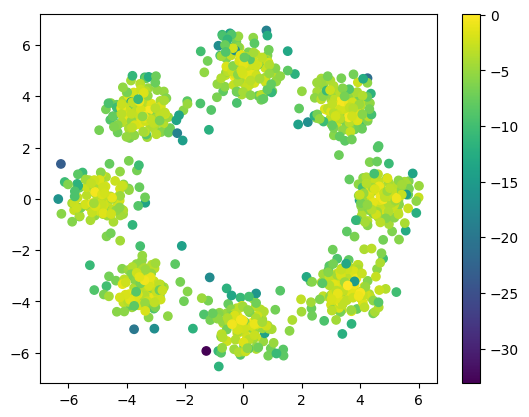

In [154]:
shape = (1024, 2)
samples, logp = sde.euler_maruyama_sample(model, shape, device, n_steps=1000)
samples = samples*(data_std + 1e-7) + data_mean 
scatter = plt.scatter(samples[:,0].detach(), samples[:,1].detach(), c=logp.detach())
plt.colorbar(scatter)

In [6]:
for i in tqdm(range(20000)):
    optimizer.zero_grad()
    x0 = torch.randn(batch_size,2)
    x1 = sample_8gaussians(batch_size)
    t, xt, ut, _ = FM.sample_location_and_conditional_flow(x0, x1, return_noise=True)
    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    #vt = (xt + (1 - t[:,None]) * score_t) / torch.clip(t[:,None], min=eps)
    #true_score_t = (t[:,None] * ut - xt) / torch.clip(1 - t[:,None], min=eps)
    #pred_score_t = (t[:,None] * vt - xt) / torch.clip(1 - t[:,None], min=eps)
    flow_loss = torch.mean((vt - ut) ** 2)
    loss = flow_loss
    loss.backward()
    optimizer.step()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [01:37<00:00, 204.78it/s]


In [7]:
torch.save(model, f"{savedir}/vector_flow_v1.pt")

In [8]:
node = NeuralODE(torch_wrapper(model), solver="euler", sensitivity="adjoint", atol=1e-4, rtol=1e-4)
x0 = torch.randn(1024,2)

with torch.no_grad():
    traj = node.trajectory(
        x0,
        t_span=torch.linspace(0, 1, 100, device=device),
    )

/network/scratch/b/bosejoey/micromamba/envs/tbg/lib/python3.11/site-packages/torchdyn/numerics/odeint.py:83: UserWarning: Setting tolerances has no effect on fixed-step methods
  warn("Setting tolerances has no effect on fixed-step methods")


In [9]:
from torch.distributions import MultivariateNormal

prior = MultivariateNormal(torch.zeros(dim, device=device), torch.eye(dim, device=device))


In [10]:
# a = t
# b = 1-t
# a_dot = 1
# b_dot = -1
# kappa = 1 / t
# eta = (1 - t) * (1 / t (1 - t) - -1)
# eta = (1 - t) * ( 1 - t + t) / t
# eta = (1 - t) / t

# sigma_t = 0.1

In [11]:
n_steps = 100
dt = 1 / n_steps
x0 = torch.randn(1024,2)
traj_sde = [x0]
xt = x0
eps = 1e-2
logp = prior.log_prob(x0)
logp2 = prior.log_prob(x0)
logps = [logp]
components = []

with torch.no_grad():
    for t in torch.linspace(0, 1 - dt, n_steps):
        sigma_t_squared = 0.001
        # sigma_t = (2 (1 - t) / t) ** 0.5
        sigma_t = sigma_t_squared ** 0.5
        sigma_t_squared = (2 * (1 - t) / torch.clip(t, min=eps))
        # sigma_t = (2 (1 - t) / t) ** 0.5
        sigma_t = sigma_t_squared ** 0.5
        vt = model(torch.cat([xt, t.repeat(1024, 1)], dim=-1))
        # st is correct we checked
        st = vt + sigma_t_squared * (t * vt - xt) / torch.clip(1-t, min=eps) / 2
        eps_t = torch.randn_like(xt)
        noise_t = sigma_t * eps_t * (dt ** 0.5)
        dxt = st * dt + noise_t
        xt = xt + dxt
        score_t = (t * vt - xt) / torch.clip(1 - t, min=eps)
        dlogp2 = ((-xt.shape[-1] / torch.clip(t, min=eps) * dt
                  + (score_t * (-sigma_t_squared / 2 * score_t * dt 
                                + dxt - xt / torch.clip(t, min=eps)) * dt).sum(-1))) 
        a = -xt.shape[-1] / torch.clip(t, min=eps) * dt * torch.ones(xt.shape[0])
        b = (sigma_t_squared / 2 * score_t * score_t).sum(-1) * dt
        c = (score_t * noise_t).sum(-1)
        dlogp = ((-xt.shape[-1] / torch.clip(t, min=eps) 
                  + (sigma_t_squared / 2 * score_t * score_t).sum(-1)) * dt
                 + (score_t * noise_t).sum(-1))
        dlogp = a + b + c
        logp = logp + dlogp
        logps.append(logp)
        components.append(torch.stack([a, b, c]))
        logp2 = logp2 + dlogp2
        traj_sde.append(xt)
traj_sde = torch.stack(traj_sde)

cnf = NeuralODE(
    cnf_wrapper(model, likelihood_estimator="exact"), 
    atol=1e-3,
    rtol=1e-3,
    solver="dopri5", sensitivity="adjoint"
)

x1 = traj_sde[-1]
device = "cpu"
steps = 1
with torch.no_grad():
    x1_with_ll = torch.cat([x1, torch.zeros(x1.shape[0], 1, device=device)], dim=-1)
    x0_with_ll = cnf.trajectory(x1_with_ll, t_span=torch.linspace(1, 0, steps + 1, device=device))[
        -1
    ]
    cnf_x0 = x0_with_ll[..., :-1]
    logprob = prior.log_prob(x0_with_ll[..., :-1]) + x0_with_ll[..., -1]

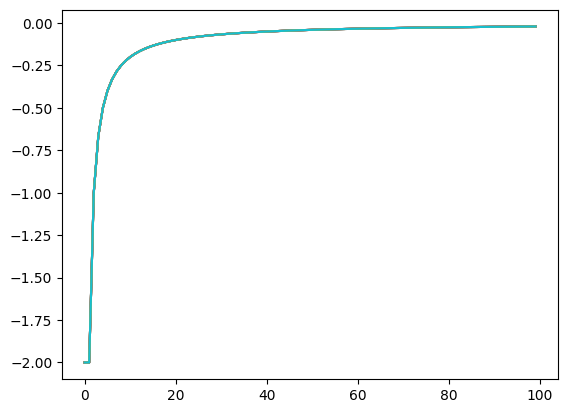

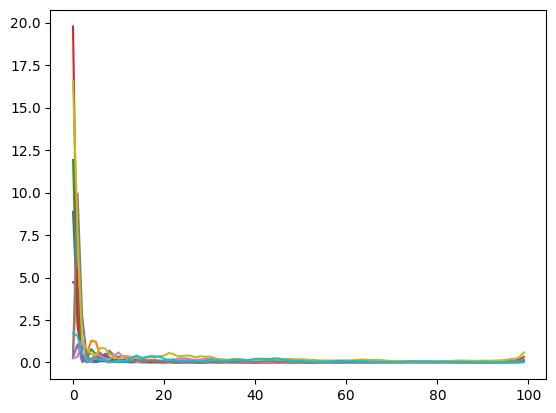

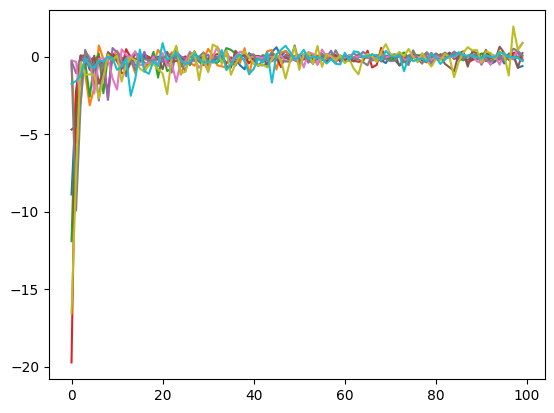

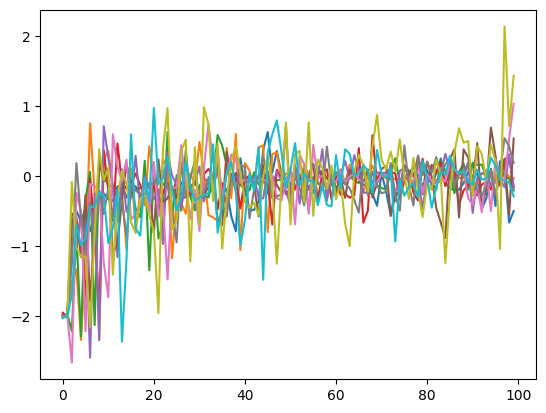

In [12]:
torch.stack(components).shape
for i in range(3):
    plot = plt.plot(torch.stack(components)[:, i, :10])
    plt.show()
plt.plot(torch.stack(components)[:, :, :10].sum(-2))

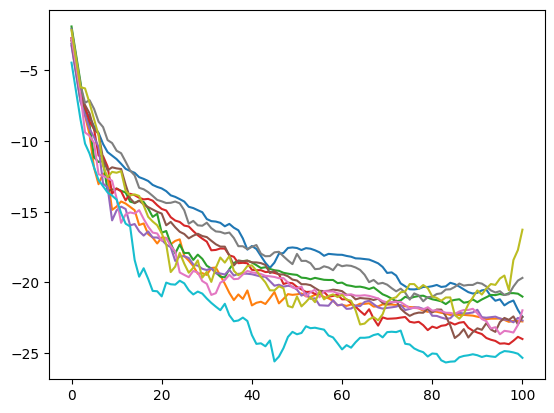

In [13]:
plot = plt.plot(torch.stack(logps)[:, :10])

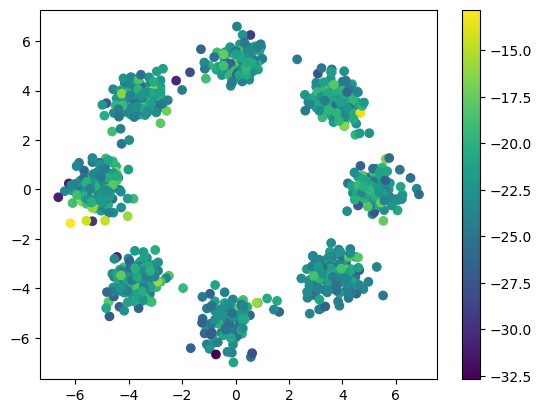

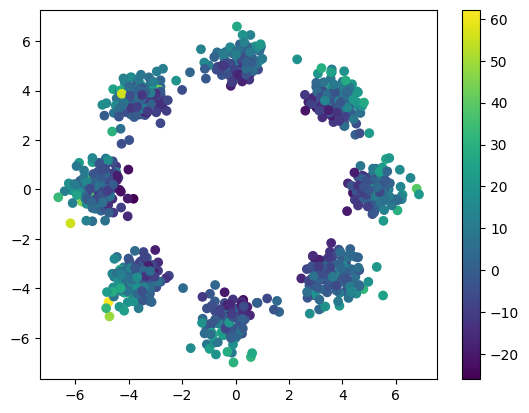

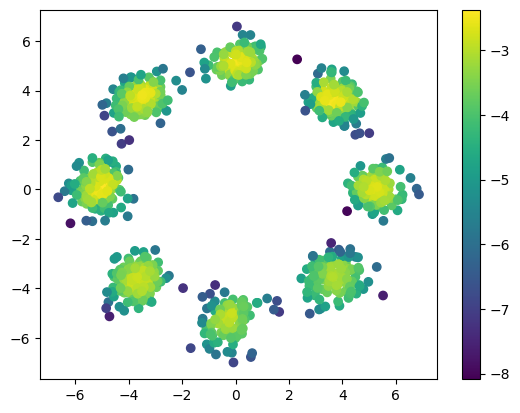

In [14]:
scatter = plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=logp.detach())
plt.colorbar(scatter)
plt.show()
scatter = plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=logp2.detach())
plt.colorbar(scatter)
plt.show()
scatter = plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=logprob.detach())
plt.colorbar(scatter)

In [15]:
n_steps = 10000
dt = 1 / n_steps
x0 = torch.randn(1024,2)
traj_sde = [x0]
xt = x0
eps = 1e-2
logp = prior.log_prob(x0)
logp2 = prior.log_prob(x0)

with torch.no_grad():
    for t in torch.linspace(0, 1, n_steps + 1):
        sigma_t_squared = (2 * (1 - t) / torch.clip(t, min=eps))
        # sigma_t = (2 (1 - t) / t) ** 0.5
        sigma_t = sigma_t_squared ** 0.5
        vt = model(torch.cat([xt, t.repeat(1024, 1)], dim=-1))
        # st is correct we checked
        st = 2 * vt - xt / torch.clip(t, min=1e-2)
        eps_t = torch.randn_like(xt)
        noise_t = sigma_t * eps_t * (dt ** 0.5)
        dxt = st * dt + noise_t
        xt = xt + dxt
        score_t = (t * vt - xt) / torch.clip(1 - t, min=eps)
        dlogp2 = ((-xt.shape[-1] / torch.clip(t, min=eps) * dt
                  + (score_t * (-sigma_t_squared / 2 * score_t * dt + dxt - xt / torch.clip(t, min=eps)) * dt).sum(-1))) 
        dlogp = ((-xt.shape[-1] / torch.clip(t, min=eps) 
                  + (sigma_t_squared / 2 * score_t * score_t).sum(-1)) * dt
                 + (score_t * noise_t).sum(-1))
        logp = logp + dlogp
        logp2 = logp2 + dlogp2
        traj_sde.append(xt)
traj_sde = torch.stack(traj_sde)

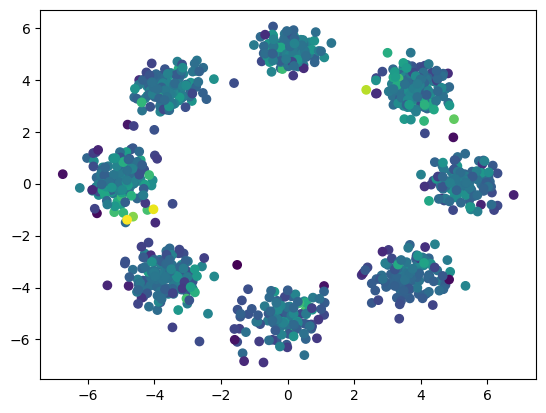

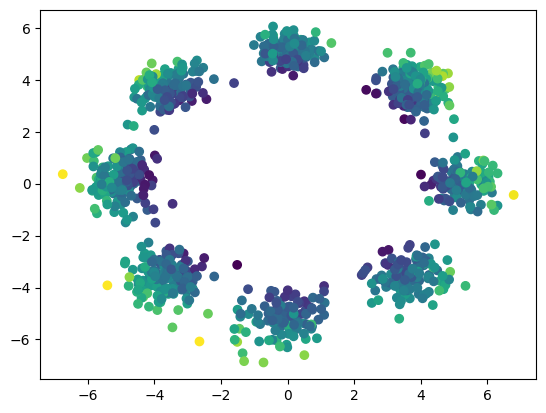

In [16]:
plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=logp.detach())
plt.show()
plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=logp2.detach())

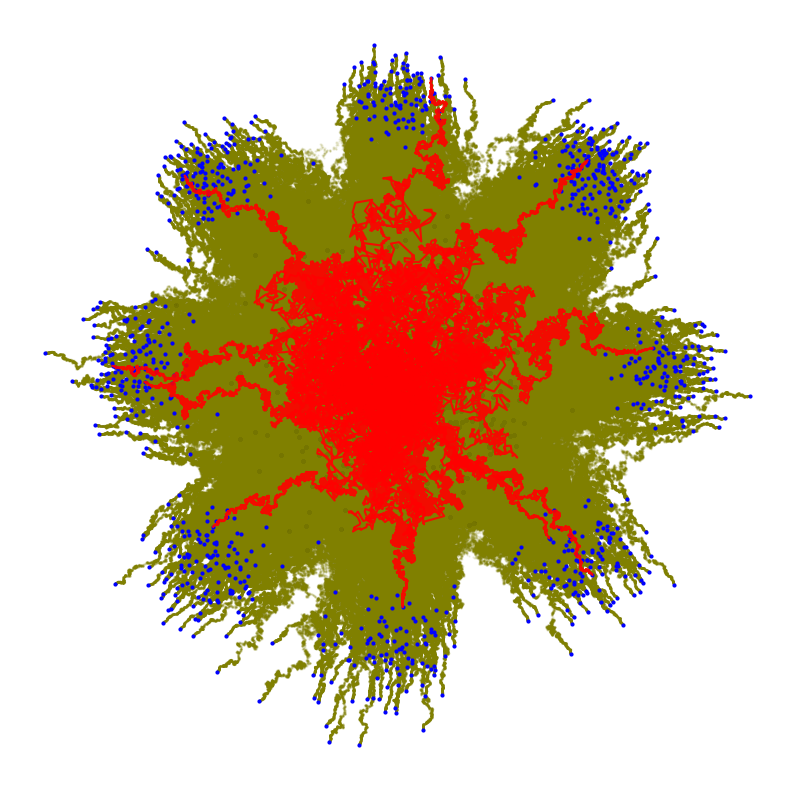

In [17]:
plot_trajectories_sb(traj_sde.detach().cpu().numpy(), legend=False)


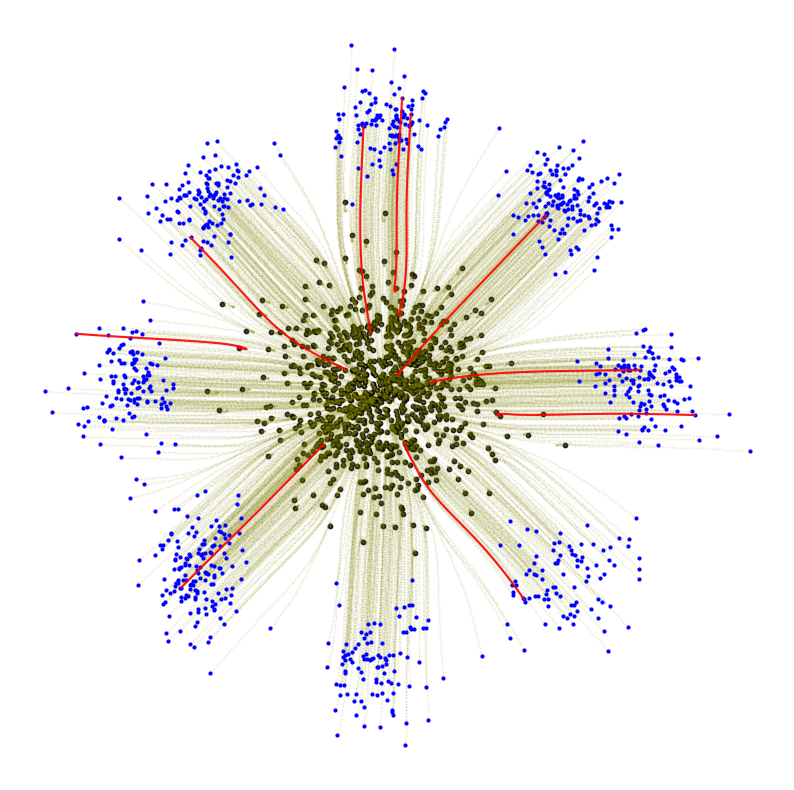

In [18]:
plot_trajectories_sb(traj.detach().cpu().numpy(), legend=False)


In [19]:
cnf = NeuralODE(
    cnf_wrapper(model, likelihood_estimator="exact"), 
    atol=1e-3,
    rtol=1e-3,
    solver="dopri5", sensitivity="adjoint"
)


x1 = traj_sde[-1]
device = "cpu"
steps = 1
with torch.no_grad():
    x1_with_ll = torch.cat([x1, torch.zeros(x1.shape[0], 1, device=device)], dim=-1)
    x0_with_ll = cnf.trajectory(x1_with_ll, t_span=torch.linspace(1, 0, steps + 1, device=device))[
        -1
    ]
    logprob = prior.log_prob(x0_with_ll[..., :-1]) + x0_with_ll[..., -1]

In [20]:
logprob

tensor([-5.8368, -2.7652, -4.8952,  ..., -2.5724, -5.7001, -3.7296])

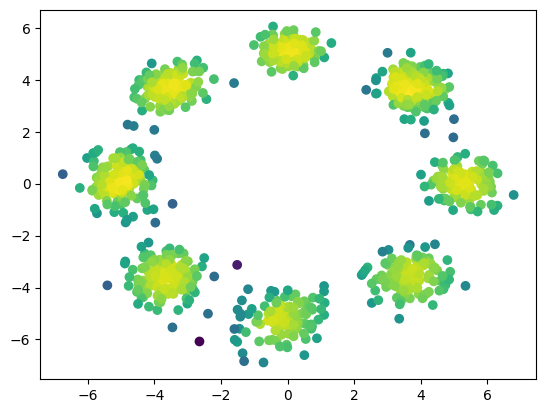

In [21]:
plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=logprob.detach())